### 1. Setup e Imports

In [19]:
import json as _json
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from tqdm import tqdm
import os
import sys
from pathlib import Path

# Agregar path del proyecto para imports
sys.path.append(os.path.abspath('../../..'))
from sae.models.sae import SparseAutoencoder
from sae.tools.naming_utils import save_checkpoint, get_model_name, get_extras_id, get_checkpoint_dir
from sae.tools.experiment_utils import get_experiment_dir, get_plots_dir, get_metrics_dir, get_report_name

# Configuración de visualización para Quarto/PDF
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', None)
np.set_printoptions(linewidth=100, precision=4)
os.environ['COLUMNS'] = '100'

# Configuración de reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Print config con formato profesional
config_df = pd.DataFrame({
    'Configuración': ['Device', 'Seed', 'Output Width'],
    'Valor': [str(device), '42', '100']
})

print('\n' + '='*50)
print(' CONFIGURACIÓN INICIAL')
print('='*50)
print(config_df.to_string(index=False))
print('='*50)


 CONFIGURACIÓN INICIAL
Configuración Valor
       Device  cuda
         Seed    42
 Output Width   100


### 2 Metadata para Naming de Checkpoints

In [20]:
# Metadata para naming de checkpoints (separada de hiperparámetros)
NAMING_META = {
    'variante': 'standard',          # Arquitectura del SAE
    'tecnica': 'l1-decay',                 # L1 con penalty annealing
    'capa': 6,                       # Layer del modelo OthelloGPT
    'juegos': 1000,                  # Número de partidas
    'base_path': 'C:\\Users\\Esposa\\Documents\\Repos\\sae-othello-gpt',  # Path base para checkpoints
    'experiment_base_path': os.path.abspath('../../../experiments') ,      # sae/experiments/
    'extras': {          
        'expansion': 32,
        'sparsity_coef': 5e-4,
        'epochs': 100,
        'patience': 10
    }
}

print('\n Metadata de naming:')
for key, value in NAMING_META.items():
    print(f'  {key}: {value}')


 Metadata de naming:
  variante: standard
  tecnica: l1-decay
  capa: 6
  juegos: 1000
  base_path: C:\Users\Esposa\Documents\Repos\sae-othello-gpt
  experiment_base_path: c:\Users\Esposa\Documents\Repos\othello_world\sae\experiments
  extras: {'expansion': 32, 'sparsity_coef': 0.0005, 'epochs': 100, 'patience': 10}


In [21]:
extras_id = get_extras_id(
    get_checkpoint_dir(
        NAMING_META['base_path'],
        NAMING_META['variante'],
        NAMING_META['tecnica'],
        NAMING_META['capa'],
        NAMING_META['juegos']
    ),
    NAMING_META['extras']
) if NAMING_META.get('extras') else None

print(f'extras_id: {extras_id}')

✓ Nuevo extras registrado: ex2 → {'expansion': 32, 'sparsity_coef': 0.0005, 'epochs': 100, 'patience': 10}
extras_id: ex2


### 3. Configuración del SAE

Las activaciones ya fueron extraídas previamente con `sae/activations/run_extraction.py`.  
Aquí especificamos qué archivo cargar y los hiperparámetros del SAE.

In [ ]:
# Configuración del SAE
CONFIG = {
    # Arquitectura
    'input_dim': 512,
    'hidden_dim': 16384,
    'tied_weights': False,
    
    # Entrenamiento
    'batch_size': 128,
    'num_epochs': 100,
    'learning_rate': 1e-3,
    'sparsity_coef': 5e-4,
    'sparsity_decay': 0.98,
    
    # Early Stopping
    'early_stopping': True,
    'patience': 10,
    
    # Datos
    'activations_file': Path(f"../../../activations/data/layer{NAMING_META['capa']}_{NAMING_META['juegos']}games.npy"),
    'save_dir': Path('./saved_model'),
    'plots_dir': get_plots_dir(
        NAMING_META['experiment_base_path'],
        NAMING_META['variante'],
        NAMING_META['tecnica'],
        NAMING_META['capa'],
        NAMING_META['juegos'],
        extras_id=extras_id
    )
}

# Crear directorio local del modelo (plots_dir ya fue creado por get_plots_dir)
CONFIG['save_dir'].mkdir(parents=True, exist_ok=True)

# Mostrar configuración con formato profesional
config_data = {
    'Categoría': [],
    'Parámetro': [],
    'Valor': []
}

# Arquitectura
for key in ['input_dim', 'hidden_dim', 'tied_weights']:
    config_data['Categoría'].append('Arquitectura')
    config_data['Parámetro'].append(key)
    config_data['Valor'].append(str(CONFIG[key]))

# Entrenamiento
for key in ['batch_size', 'num_epochs', 'learning_rate', 'sparsity_coef', 'sparsity_decay']:
    config_data['Categoría'].append('Entrenamiento')
    config_data['Parámetro'].append(key)
    config_data['Valor'].append(str(CONFIG[key]))

# Early Stopping
for key in ['early_stopping', 'patience']:
    config_data['Categoría'].append('Early Stopping')
    config_data['Parámetro'].append(key)
    config_data['Valor'].append(str(CONFIG[key]))

config_table = pd.DataFrame(config_data)

print('\n' + '='*70)
print(' CONFIGURACIÓN DEL SAE')
print('='*70)
print(config_table.to_string(index=False))
print('='*70)

print(f'\nArchivo de activaciones: {CONFIG["activations_file"]}')
print(f'Expansión: {CONFIG["hidden_dim"]/CONFIG["input_dim"]:.1f}x')
print(f'Plots dir: {CONFIG["plots_dir"]}')
print('='*70)


 CONFIGURACIÓN DEL SAE
     Categoría      Parámetro  Valor
  Arquitectura      input_dim    512
  Arquitectura     hidden_dim  16384
  Arquitectura   tied_weights  False
 Entrenamiento     batch_size    128
 Entrenamiento     num_epochs    100
 Entrenamiento  learning_rate  0.001
 Entrenamiento  sparsity_coef 0.0005
 Entrenamiento sparsity_decay   0.95
Early Stopping early_stopping   True
Early Stopping       patience     10

Archivo de activaciones: ..\..\..\activations\data\layer6_1000games.npy
Expansión: 32.0x
Plots dir: c:\Users\Esposa\Documents\Repos\othello_world\sae\experiments\layer_06\sae_standard\sae_l1-decay_standard\1000games\ex2\plots


### 4. Dataset de Activaciones (Train/Validation Split 80-20%)

In [23]:
class ActivationsDataset(Dataset):
    """Dataset para cargar activaciones extraídas"""
    
    def __init__(self, activations_path):
        self.activations = np.load(activations_path)
    
    def __len__(self):
        return len(self.activations)
    
    def __getitem__(self, idx):
        return torch.tensor(self.activations[idx], dtype=torch.float32)

# Cargar dataset completo
full_dataset = ActivationsDataset(CONFIG['activations_file'])

# Información del dataset con formato profesional
dataset_info = pd.DataFrame({
    'Propiedad': ['Total muestras', 'Shape', 'Dtype', 'Tamaño en memoria'],
    'Valor': [
        f"{len(full_dataset):,}",
        str(full_dataset.activations.shape),
        str(full_dataset.activations.dtype),
        f"{full_dataset.activations.nbytes / 1024**2:.2f} MB"
    ]
})
print('\n' + '='*50)
print(' DATASET DE ACTIVACIONES')
print('='*50)
print(dataset_info.to_string(index=False))
print('='*50)

# Split train/validation (80-20)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(
    full_dataset, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# Resumen del split con formato profesional
split_info = pd.DataFrame({
    'Conjunto': ['Train', 'Validation', 'Total'],
    'Muestras': [
        f"{len(train_dataset):,}",
        f"{len(val_dataset):,}",
        f"{len(full_dataset):,}"
    ],
    'Porcentaje': [
        f"{len(train_dataset)/len(full_dataset):.1%}",
        f"{len(val_dataset)/len(full_dataset):.1%}",
        "100.0%"
    ]
})
print('\n' + '='*50)
print(' SPLIT DE DATOS (80-20)')
print('='*50)
print(split_info.to_string(index=False))
print('='*50)

# Crear DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=0,
    pin_memory=(device.type == 'cuda')
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,  # No shuffle para validación
    num_workers=0,
    pin_memory=(device.type == 'cuda')
)

# Resumen de DataLoaders
loader_info = pd.DataFrame({
    'DataLoader': ['Train', 'Validation'],
    'Batches': [len(train_loader), len(val_loader)],
    'Batch Size': [CONFIG['batch_size'], CONFIG['batch_size']],
    'Shuffle': ['Sí', 'No']
})

print('\n' + '='*50)
print(' DATALOADERS')
print('='*50)
print(loader_info.to_string(index=False))
print('='*50)


 DATASET DE ACTIVACIONES
        Propiedad        Valor
   Total muestras       59,000
            Shape (59000, 512)
            Dtype      float32
Tamaño en memoria    115.23 MB

 SPLIT DE DATOS (80-20)
  Conjunto Muestras Porcentaje
     Train   47,200      80.0%
Validation   11,800      20.0%
     Total   59,000     100.0%

 DATALOADERS
DataLoader  Batches  Batch Size Shuffle
     Train      369         128      Sí
Validation       93         128      No


### 5. Modelo: Sparse Autoencoder

Modelo importado desde `sae.models.sae.SparseAutoencoder`

**Arquitectura:**

- **Encoder**: Linear → ReLU (sparsity natural)- **Decoder**: Linear (reconstrucción)

In [24]:
# Crear modelo desde el módulo
model = SparseAutoencoder(
    input_dim=CONFIG['input_dim'],
    hidden_dim=CONFIG['hidden_dim'],
    tied_weights=CONFIG['tied_weights']
).to(device)

# Calcular parámetros
num_params = sum(p.numel() for p in model.parameters())
encoder_params = sum(p.numel() for p in model.encoder.parameters())
if CONFIG['tied_weights']:
    decoder_params = CONFIG['input_dim']  # Solo bias
else:
    decoder_params = sum(p.numel() for p in model.decoder.parameters())

# Resumen del modelo con formato profesional
model_info = pd.DataFrame({
    'Componente': ['Input', 'Encoder', 'Hidden (Latent)', 'Decoder', 'Output', 'Total'],
    'Dimensión': [
        CONFIG['input_dim'],
        f"{CONFIG['input_dim']} → {CONFIG['hidden_dim']}",
        CONFIG['hidden_dim'],
        f"{CONFIG['hidden_dim']} → {CONFIG['input_dim']}",
        CONFIG['input_dim'],
        '-'
    ],
    'Parámetros': [
        '-',
        f"{encoder_params:,}",
        '-',
        f"{decoder_params:,}",
        '-',
        f"{num_params:,}"
    ]
})

print('\n' + '='*70)
print(' ARQUITECTURA DEL MODELO')
print('='*70)
print(model_info.to_string(index=False))
print('='*70)
print(f'\n Factor de expansión: {CONFIG["hidden_dim"]/CONFIG["input_dim"]:.1f}x')
print(f' Tied weights: {"Sí" if CONFIG["tied_weights"] else "No"}')
print(f' Device: {device}')
print('='*70)


 ARQUITECTURA DEL MODELO
     Componente   Dimensión Parámetros
          Input         512          -
        Encoder 512 → 16384  8,404,992
Hidden (Latent)       16384          -
        Decoder 16384 → 512  8,389,120
         Output         512          -
          Total           - 16,794,112

 Factor de expansión: 32.0x
 Tied weights: No
 Device: cuda


### 6. Función de Pérdida

**Loss = MSE(reconstrucción) + λ × L1(activaciones)**

- **MSE**: Mide qué tan bien reconstruimos las activaciones originales
- **L1**: Penaliza activaciones grandes → fuerza sparsity

In [25]:
def loss_function(x, reconstruction, hidden, sparsity_coef):
    """
    Pérdida compuesta: MSE + L1 penalty
    
    Args:
        x: Activaciones originales
        reconstruction: Activaciones reconstruidas
        hidden: Activaciones latentes (sparse)
        sparsity_coef: Peso de la penalización L1
    """
    # Error de reconstrucción
    mse_loss = F.mse_loss(reconstruction, x)
    
    # Sumar sobre las features (dim=1), promediar sobre el batch
    sparsity_loss = hidden.abs().sum(dim=1).mean()
    
    # Pérdida total
    total_loss = mse_loss + sparsity_coef * sparsity_loss
    
    return total_loss, mse_loss, sparsity_loss

# Optimizador
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG['learning_rate'])

# Resumen del optimizador
optim_info = pd.DataFrame({
    'Parámetro': ['Optimizador', 'Learning Rate', 'Sparsity Coef (inicial)', 'Sparsity Decay'],
    'Valor': [
        'Adam',
        f"{CONFIG['learning_rate']:.0e}",
        f"{CONFIG['sparsity_coef']:.0e}",
        f"{CONFIG['sparsity_decay']:.2f}"
    ]
})

print('\n' + '='*50)
print(' OPTIMIZACIÓN')
print('='*50)
print(optim_info.to_string(index=False))
print('='*50)


 OPTIMIZACIÓN
              Parámetro Valor
            Optimizador  Adam
          Learning Rate 1e-03
Sparsity Coef (inicial) 5e-04
         Sparsity Decay  0.95


### 7. Loop de Entrenamiento

In [ ]:
# Historial de entrenamiento
history = {
    'train_total_loss': [],
    'train_mse_loss': [],
    'train_sparsity_loss': [],
    'train_l0_sparsity': [],
    'train_fraction_active': [],
    'val_total_loss': [],
    'val_mse_loss': [],
    'val_sparsity_loss': [],
    'val_l0_sparsity': [],
    'val_fraction_active': [],
    'sparsity_coef_history': []  # Guardar evolución del coeficiente L1
}

# Early stopping variables
best_val_mse = float('inf')
best_epoch = 0
epochs_no_improve = 0

print(f'\n Iniciando entrenamiento: {CONFIG["num_epochs"]} épocas máximo')
print(f' L1 decay: {CONFIG["sparsity_coef"]:.2e} × {CONFIG["sparsity_decay"]:.2f}^época')
print(f'⏸  Early stopping: patience={CONFIG["patience"]} épocas')
print('=' * 70)

for epoch in range(CONFIG['num_epochs']):
    # ========== L1 DECAY ==========
    # Reducir sparsity_coef exponencialmente
    current_sparsity_coef = CONFIG['sparsity_coef'] * (CONFIG['sparsity_decay'] ** epoch)
    history['sparsity_coef_history'].append(current_sparsity_coef)
    
    # ========== ENTRENAMIENTO ==========
    model.train()
    
    epoch_total_loss = 0
    epoch_mse_loss = 0
    epoch_sparsity_loss = 0
    epoch_l0 = 0
    epoch_fraction_active = 0
    
    # Barra de progreso
    pbar = tqdm(train_loader, desc=f'Época {epoch+1}/{CONFIG["num_epochs"]} [Train] L1={current_sparsity_coef:.2e}')
    
    for batch in pbar:
        # Mover al device
        x = batch.to(device)
        
        # Forward pass
        reconstruction, hidden = model(x)
        
        # Calcular pérdida con sparsity_coef actualizado
        total_loss, mse_loss, sparsity_loss = loss_function(
            x, reconstruction, hidden, current_sparsity_coef
        )
        
        # Backward pass
        optimizer.zero_grad()
        total_loss.backward()
        
        optimizer.step()
        
        # Métricas
        with torch.no_grad():
            l0 = (hidden > 0).float().sum(dim=1).mean().item()
            fraction_active = (hidden > 0).float().mean().item()
        
        # Acumular
        epoch_total_loss += total_loss.item()
        epoch_mse_loss += mse_loss.item()
        epoch_sparsity_loss += sparsity_loss.item()
        epoch_l0 += l0
        epoch_fraction_active += fraction_active
        
        # Actualizar barra
        pbar.set_postfix({
            'loss': f'{total_loss.item():.4f}',
            'mse': f'{mse_loss.item():.4f}',
            'l0': f'{l0:.1f}'
        })
    
    # Promedios de entrenamiento
    num_train_batches = len(train_loader)
    avg_train_total_loss = epoch_total_loss / num_train_batches
    avg_train_mse_loss = epoch_mse_loss / num_train_batches
    avg_train_sparsity_loss = epoch_sparsity_loss / num_train_batches
    avg_train_l0 = epoch_l0 / num_train_batches
    avg_train_fraction_active = epoch_fraction_active / num_train_batches
    
    # ========== VALIDACIÓN ==========
    model.eval()
    
    val_total_loss = 0
    val_mse_loss = 0
    val_sparsity_loss = 0
    val_l0 = 0
    val_fraction_active = 0
    
    with torch.no_grad():
        for batch in val_loader:
            x = batch.to(device)
            
            # Forward pass
            reconstruction, hidden = model(x)
            
            # Calcular pérdida con sparsity_coef actualizado
            total_loss, mse_loss, sparsity_loss = loss_function(
                x, reconstruction, hidden, current_sparsity_coef
            )
            
            # Métricas
            l0 = (hidden > 0).float().sum(dim=1).mean().item()
            fraction_active = (hidden > 0).float().mean().item()
            
            # Acumular
            val_total_loss += total_loss.item()
            val_mse_loss += mse_loss.item()
            val_sparsity_loss += sparsity_loss.item()
            val_l0 += l0
            val_fraction_active += fraction_active
    
    # Promedios de validación
    num_val_batches = len(val_loader)
    avg_val_total_loss = val_total_loss / num_val_batches
    avg_val_mse_loss = val_mse_loss / num_val_batches
    avg_val_sparsity_loss = val_sparsity_loss / num_val_batches
    avg_val_l0 = val_l0 / num_val_batches
    avg_val_fraction_active = val_fraction_active / num_val_batches
    
    # Guardar en historial
    history['train_total_loss'].append(avg_train_total_loss)
    history['train_mse_loss'].append(avg_train_mse_loss)
    history['train_sparsity_loss'].append(avg_train_sparsity_loss)
    history['train_l0_sparsity'].append(avg_train_l0)
    history['train_fraction_active'].append(avg_train_fraction_active)
    
    history['val_total_loss'].append(avg_val_total_loss)
    history['val_mse_loss'].append(avg_val_mse_loss)
    history['val_sparsity_loss'].append(avg_val_sparsity_loss)
    history['val_l0_sparsity'].append(avg_val_l0)
    history['val_fraction_active'].append(avg_val_fraction_active)
    
    # ========== EARLY STOPPING ==========
    if CONFIG['early_stopping']:
        if avg_val_mse_loss < best_val_mse:
            best_val_mse = avg_val_mse_loss
            best_epoch = epoch + 1
            epochs_no_improve = 0
            
            # Guardar mejor modelo (local + organizado)
            best_checkpoint = {
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'config': CONFIG,
                'history': history,
                'epoch': best_epoch,
                'val_mse': best_val_mse
            }
            
            # Guardado local
            best_model_name = get_model_name(
                variante=NAMING_META['variante'],
                tecnica=NAMING_META['tecnica'],
                capa=NAMING_META['capa'],
                juegos=NAMING_META['juegos'],
                estado='best'
            )
            torch.save(best_checkpoint, CONFIG['save_dir'] / best_model_name)
            
            # Guardado organizado
            save_checkpoint(
                model, 
                base_path=NAMING_META['base_path'],
                variante=NAMING_META['variante'],
                tecnica=NAMING_META['tecnica'],
                capa=NAMING_META['capa'],
                juegos=NAMING_META['juegos'],
                estado='best',
                extras=NAMING_META['extras'],
                config=CONFIG,
                history=history,
                optimizer=optimizer
            )
            
            print(f' Mejor modelo guardado en época {best_epoch} (Val MSE: {best_val_mse:.4f})')
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= CONFIG['patience']:
                print(f'\n⏸  Early stopping activado en época {epoch+1}')
                print(f'   Mejor modelo: época {best_epoch} con Val MSE = {best_val_mse:.4f}')
                break
    
    # Log cada 5 épocas
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'\n Época {epoch+1}/{CONFIG["num_epochs"]} | L1 coef: {current_sparsity_coef:.2e}')
        print(f'  Train - Total: {avg_train_total_loss:.4f} | MSE: {avg_train_mse_loss:.4f} | L0: {avg_train_l0:.1f}')
        print(f'  Val   - Total: {avg_val_total_loss:.4f} | MSE: {avg_val_mse_loss:.4f} | L0: {avg_val_l0:.1f}')
        if CONFIG['early_stopping']:
            print(f'   Best Val MSE: {best_val_mse:.4f} @ época {best_epoch} | Sin mejora: {epochs_no_improve}/{CONFIG["patience"]}')

print('\n' + '='*70)
print(' RESUMEN DEL ENTRENAMIENTO')
print('='*70)

if CONFIG['early_stopping']:
    print(f'Mejor modelo en época {best_epoch} con Val MSE = {best_val_mse:.4f}')
    print(f'Early stopping tras {len(history["train_total_loss"])} épocas')
else:
    print(f'Entrenamiento completo: {CONFIG["num_epochs"]} épocas')

# Tabla de métricas finales
final_metrics = pd.DataFrame({
    'Métrica': ['Total Loss', 'MSE Loss', 'L0 Sparsity', 'Fraction Active'],
    'Train': [
        f"{history['train_total_loss'][-1]:.4f}",
        f"{history['train_mse_loss'][-1]:.4f}",
        f"{history['train_l0_sparsity'][-1]:.1f}",
        f"{history['train_fraction_active'][-1]:.2%}"
    ],
    'Validation': [
        f"{history['val_total_loss'][-1]:.4f}",
        f"{history['val_mse_loss'][-1]:.4f}",
        f"{history['val_l0_sparsity'][-1]:.1f}",
        f"{history['val_fraction_active'][-1]:.2%}"
    ]
})

print('\nMétricas Finales (Última Época):')
print(final_metrics.to_string(index=False))
print('='*70)



 Iniciando entrenamiento: 100 épocas máximo
 L1 decay: 5.00e-04 × 0.95^época
⏸  Early stopping: patience=10 épocas


Época 1/100 [Train] L1=5.00e-04:   0%|          | 0/369 [00:00<?, ?it/s]

Época 1/100 [Train] L1=5.00e-04: 100%|██████████| 369/369 [00:03<00:00, 114.98it/s, loss=0.1759, mse=0.0644, l0=1087.8]


✓ Checkpoint guardado: C:\Users\Esposa\Documents\Repos\sae-othello-gpt\layer_06\models\sae_standard\sae_l1-decay_standard\1000games\sae_standard_l1-decay_l6_1000g_ex2_best.pt
 Mejor modelo guardado en época 1 (Val MSE: 0.0659)

 Época 1/100 | L1 coef: 5.00e-04
  Train - Total: 0.3714 | MSE: 0.2648 | L0: 1132.7
  Val   - Total: 0.1766 | MSE: 0.0659 | L0: 1089.9
   Best Val MSE: 0.0659 @ época 1 | Sin mejora: 0/10


Época 2/100 [Train] L1=4.75e-04: 100%|██████████| 369/369 [00:03<00:00, 120.35it/s, loss=0.1563, mse=0.0579, l0=1075.4]


...


 Época 5/100 | L1 coef: 4.07e-04
  Train - Total: 0.1220 | MSE: 0.0477 | L0: 954.9
  Val   - Total: 0.1339 | MSE: 0.0597 | L0: 963.0
   Best Val MSE: 0.0560 @ época 3 | Sin mejora: 2/10


Época 10/100 [Train] L1=3.15e-04: 100%|██████████| 369/369 [00:03<00:00, 121.55it/s, loss=0.1023, mse=0.0473, l0=836.8]



 Época 10/100 | L1 coef: 3.15e-04
  Train - Total: 0.0973 | MSE: 0.0437 | L0: 822.6
  Val   - Total: 0.1115 | MSE: 0.0586 | L0: 832.3
   Best Val MSE: 0.0560 @ época 3 | Sin mejora: 7/10


Época 13/100 [Train] L1=2.70e-04: 100%|██████████| 369/369 [00:02<00:00, 123.32it/s, loss=0.0927, mse=0.0472, l0=761.5]



⏸  Early stopping activado en época 13
   Mejor modelo: época 3 con Val MSE = 0.0560

 RESUMEN DEL ENTRENAMIENTO
Mejor modelo en época 3 con Val MSE = 0.0560
Early stopping tras 13 épocas

Métricas Finales (Última Época):
        Métrica  Train Validation
     Total Loss 0.0888     0.1078
       MSE Loss 0.0434     0.0623
    L0 Sparsity  773.2      788.3
Fraction Active  4.72%      4.81%


### 8. Guardar Modelo

In [11]:
# Guardar checkpoint final (local + organizado)
checkpoint = {
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'config': CONFIG,
    'history': history
}

# Guardado local
final_model_name = get_model_name(
    variante=NAMING_META['variante'],
    tecnica=NAMING_META['tecnica'],
    capa=NAMING_META['capa'],
    juegos=NAMING_META['juegos'],
    estado='final'
)
checkpoint_path = CONFIG['save_dir'] / final_model_name
torch.save(checkpoint, checkpoint_path)

# Guardado organizado
save_checkpoint(
    model, 
    base_path=NAMING_META['base_path'],
    variante=NAMING_META['variante'],
    tecnica=NAMING_META['tecnica'],
    capa=NAMING_META['capa'],
    juegos=NAMING_META['juegos'],
    estado='final',
    extras=NAMING_META['extras'],
    config=CONFIG,
    history=history,
    optimizer=optimizer
)

# Resumen de archivos guardados
saved_files = pd.DataFrame({
    'Tipo': ['Local', 'Organizado'],
    'Ubicación': [
        str(checkpoint_path),
        f"layer_{NAMING_META['capa']:02d}/models/..."
    ]
})

print('\n' + '='*70)
print(' CHECKPOINTS GUARDADOS')
print('='*70)
print(saved_files.to_string(index=False))
print('='*70)

✓ Checkpoint guardado: C:\Users\Esposa\Documents\Repos\sae-othello-gpt\layer_06\models\sae_standard\sae_l1-decay_standard\200games\sae_standard_l1-decay_l6_200g_ex1_final.pt

 CHECKPOINTS GUARDADOS
      Tipo                                          Ubicación
     Local saved_model\sae_standard_l1-decay_l6_200g_final.pt
Organizado                                layer_06/models/...


### 9. Métricas básicas del modelo

In [12]:
# Guardar metricas de entrenamiento
metrics_dir = get_metrics_dir(
    NAMING_META["experiment_base_path"],
    NAMING_META["variante"],
    NAMING_META["tecnica"],
    NAMING_META["capa"],
    NAMING_META["juegos"],
    extras_id=extras_id
)

training_metrics = {
    # Metricas de calidad
    "val_mse_final": history["val_mse_loss"][-1],
    "val_mse_best": best_val_mse,
    "val_l0_final": history["val_l0_sparsity"][-1],
    "val_fraction_active_final": history["val_fraction_active"][-1],
    # Contexto del entrenamiento
    "best_epoch": best_epoch,
    "total_epochs": len(history["train_total_loss"]),
    "train_mse_final": history["train_mse_loss"][-1],
    "train_l0_final": history["train_l0_sparsity"][-1],
    # Hiperparametros
    "hidden_dim": CONFIG["hidden_dim"],
    "expansion_factor": CONFIG["hidden_dim"] / CONFIG["input_dim"],
    "sparsity_coef": CONFIG["sparsity_coef"],
    "sparsity_decay": CONFIG["sparsity_decay"],
    "learning_rate": CONFIG["learning_rate"],
    "num_games": NAMING_META["juegos"],
}

metrics_path = metrics_dir / "training_metrics.json"
with open(metrics_path, "w") as f:
    _json.dump(training_metrics, f, indent=2)

# Resumen
metrics_df = pd.DataFrame({
    "Metrica": ["Val MSE (final)", "Val MSE (mejor)", "Val L0 (final)", "Fraccion Activa"],
    "Valor": [
        f"{training_metrics['val_mse_final']:.6f}",
        f"{training_metrics['val_mse_best']:.6f}",
        f"{training_metrics['val_l0_final']:.1f}",
        f"{training_metrics['val_fraction_active_final']:.2%}"
    ]
})
print("" + "="*50)
print(" METRICAS DE ENTRENAMIENTO GUARDADAS")
print("="*50)
print(metrics_df.to_string(index=False))
print(f"Archivo: {metrics_path}")
print("="*50)


 METRICAS DE ENTRENAMIENTO GUARDADAS
        Metrica    Valor
Val MSE (final) 0.069633
Val MSE (mejor) 0.068534
 Val L0 (final)    974.6
Fraccion Activa   11.90%
Archivo: c:\Users\Esposa\Documents\Repos\othello_world\sae\experiments\layer_06\sae_standard\sae_l1-decay_standard\200games\ex1\metrics\training_metrics.json


### 10. Visualización de Resultados

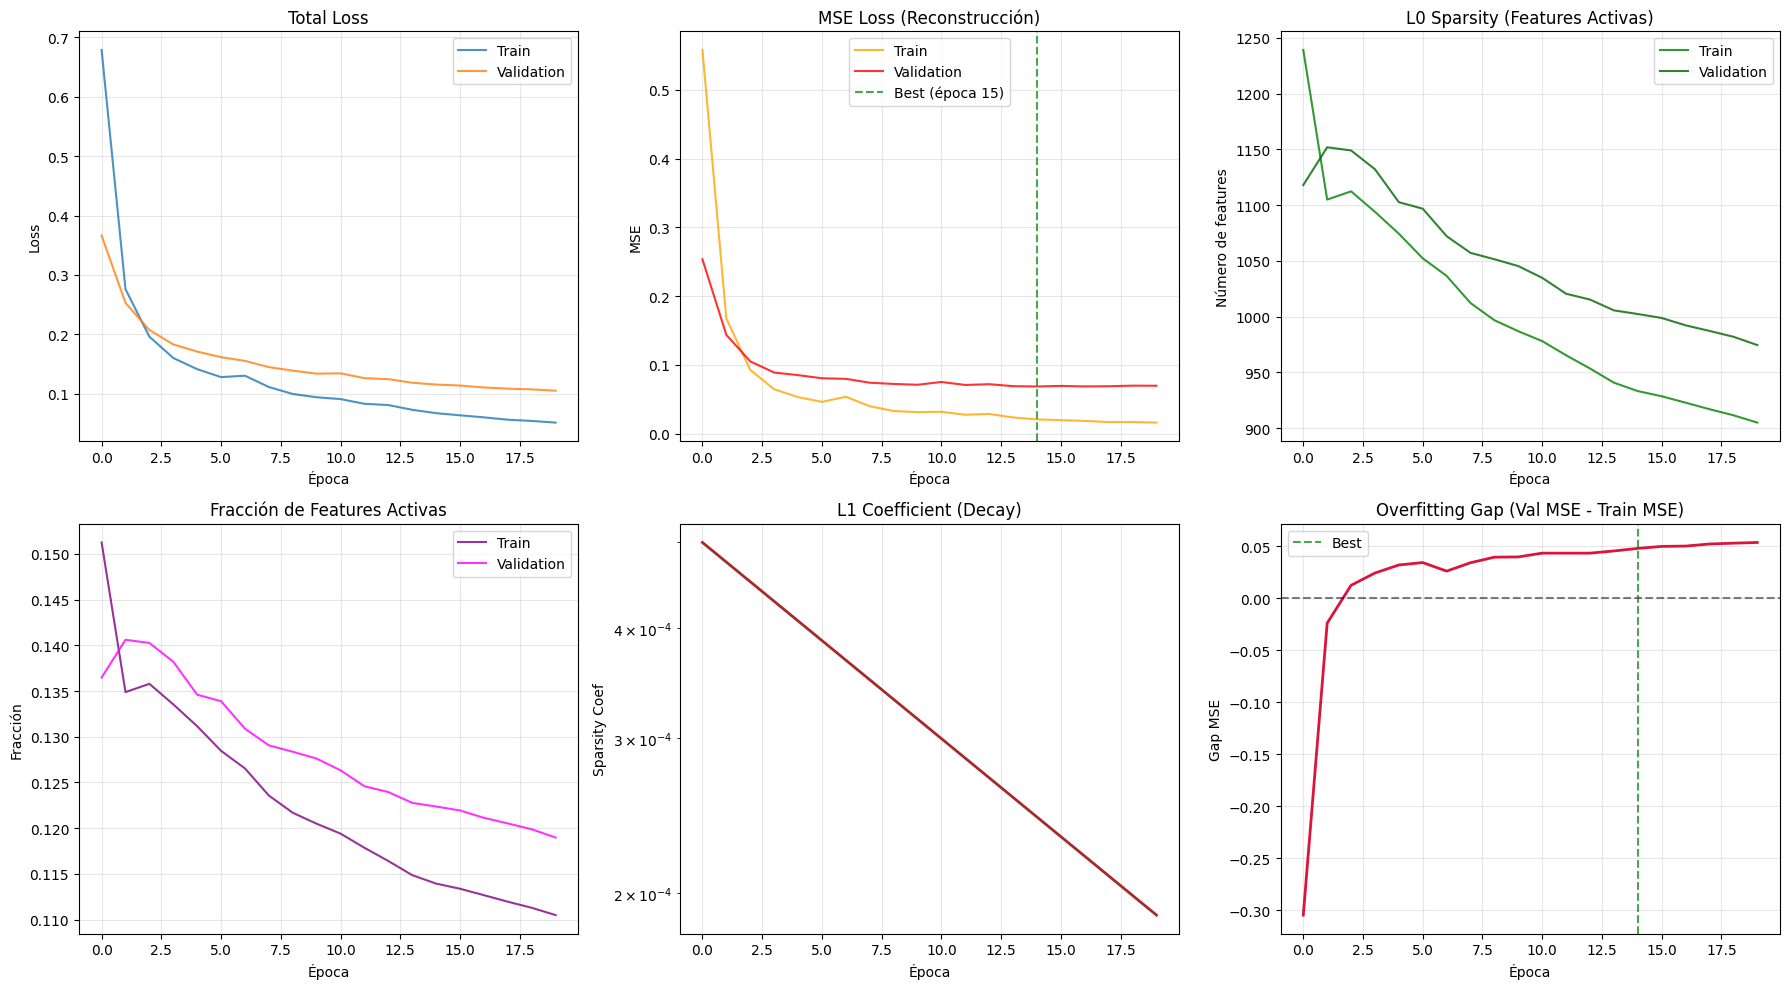


 ✓ Gráficas guardadas exitosamente


In [13]:
# Gráficas de pérdidas (Train vs Validation) + L1 Decay
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Total loss
axes[0, 0].plot(history['train_total_loss'], label='Train', alpha=0.8)
axes[0, 0].plot(history['val_total_loss'], label='Validation', alpha=0.8)
axes[0, 0].set_title('Total Loss')
axes[0, 0].set_xlabel('Época')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# MSE loss
axes[0, 1].plot(history['train_mse_loss'], label='Train', color='orange', alpha=0.8)
axes[0, 1].plot(history['val_mse_loss'], label='Validation', color='red', alpha=0.8)
if CONFIG['early_stopping'] and best_epoch > 0:
    axes[0, 1].axvline(best_epoch - 1, color='green', linestyle='--', alpha=0.7, label=f'Best (época {best_epoch})')
axes[0, 1].set_title('MSE Loss (Reconstrucción)')
axes[0, 1].set_xlabel('Época')
axes[0, 1].set_ylabel('MSE')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# L0 sparsity
axes[0, 2].plot(history['train_l0_sparsity'], label='Train', color='green', alpha=0.8)
axes[0, 2].plot(history['val_l0_sparsity'], label='Validation', color='darkgreen', alpha=0.8)
axes[0, 2].set_title('L0 Sparsity (Features Activas)')
axes[0, 2].set_xlabel('Época')
axes[0, 2].set_ylabel('Número de features')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Fraction active
axes[1, 0].plot(history['train_fraction_active'], label='Train', color='purple', alpha=0.8)
axes[1, 0].plot(history['val_fraction_active'], label='Validation', color='magenta', alpha=0.8)
axes[1, 0].set_title('Fracción de Features Activas')
axes[1, 0].set_xlabel('Época')
axes[1, 0].set_ylabel('Fracción')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Sparsity Coefficient (L1 Decay)
axes[1, 1].plot(history['sparsity_coef_history'], color='brown', linewidth=2)
axes[1, 1].set_title('L1 Coefficient (Decay)')
axes[1, 1].set_xlabel('Época')
axes[1, 1].set_ylabel('Sparsity Coef')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.3)

# Train vs Val MSE Gap
mse_gap = [v - t for v, t in zip(history['val_mse_loss'], history['train_mse_loss'])]
axes[1, 2].plot(mse_gap, color='crimson', linewidth=2)
axes[1, 2].axhline(0, color='black', linestyle='--', alpha=0.5)
if CONFIG['early_stopping'] and best_epoch > 0:
    axes[1, 2].axvline(best_epoch - 1, color='green', linestyle='--', alpha=0.7, label=f'Best')
axes[1, 2].set_title('Overfitting Gap (Val MSE - Train MSE)')
axes[1, 2].set_xlabel('Época')
axes[1, 2].set_ylabel('Gap MSE')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(CONFIG['plots_dir'] / 'training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n' + '='*50)
print(' ✓ Gráficas guardadas exitosamente')

print('='*50)

### 11. Resumen Final

In [14]:
# Resumen final completo
print('\n' + '='*70)
print(' RESUMEN FINAL DEL ENTRENAMIENTO')
print('='*70)

# Arquitectura
arch_summary = pd.DataFrame({
    'Componente': ['Input', 'Hidden', 'Parámetros'],
    'Valor': [
        f"{CONFIG['input_dim']}",
        f"{CONFIG['hidden_dim']} ({CONFIG['hidden_dim']/CONFIG['input_dim']:.1f}x)",
        f"{num_params:,}"
    ]
})
print('\nArquitectura:')
print(arch_summary.to_string(index=False))

# Datos
data_summary = pd.DataFrame({
    'Conjunto': ['Train', 'Validation', 'Total'],
    'Muestras': [
        f"{len(train_dataset):,}",
        f"{len(val_dataset):,}",
        f"{len(full_dataset):,}"
    ]
})
print('\nDatos:')
print(data_summary.to_string(index=False))

# Métricas finales
final_summary = pd.DataFrame({
    'Métrica': ['Train Loss', 'Val Loss', 'Train MSE', 'Val MSE', 'Train L0', 'Val L0'],
    'Valor': [
        f"{history['train_total_loss'][-1]:.4f}",
        f"{history['val_total_loss'][-1]:.4f}",
        f"{history['train_mse_loss'][-1]:.4f}",
        f"{history['val_mse_loss'][-1]:.4f}",
        f"{history['train_l0_sparsity'][-1]:.1f}",
        f"{history['val_l0_sparsity'][-1]:.1f}"
    ]
})
print('\nMétricas Finales:')
print(final_summary.to_string(index=False))

# Archivos
files_summary = pd.DataFrame({
    'Tipo': ['Modelo', 'Gráficas'],
    'Ubicación': [
        str(checkpoint_path),
        str(CONFIG['plots_dir'] / 'training_curves.png')
    ]
})
print('\nArchivos Guardados:')
print(files_summary.to_string(index=False))

print('\n' + '='*70)
print(' ✓ ENTRENAMIENTO COMPLETADO EXITOSAMENTE')
print('='*70)


 RESUMEN FINAL DEL ENTRENAMIENTO

Arquitectura:
Componente        Valor
     Input          512
    Hidden 8192 (16.0x)
Parámetros    8,397,312

Datos:
  Conjunto Muestras
     Train    9,440
Validation    2,360
     Total   11,800

Métricas Finales:
   Métrica  Valor
Train Loss 0.0516
  Val Loss 0.1052
 Train MSE 0.0160
   Val MSE 0.0696
  Train L0  905.1
    Val L0  974.6

Archivos Guardados:
    Tipo                                                                                                                                        Ubicación
  Modelo                                                                                               saved_model\sae_standard_l1-decay_l6_200g_final.pt
Gráficas c:\Users\Esposa\Documents\Repos\othello_world\sae\experiments\layer_06\sae_standard\sae_l1-decay_standard\200games\ex1\plots\training_curves.png

 ✓ ENTRENAMIENTO COMPLETADO EXITOSAMENTE


### 12. Generar PDF con Quarto

Una vez ejecutado todo el notebook, ejecutar el siguiente comando en la terminal para generar el PDF con Quarto:

In [ ]:
import subprocess

# Obtener directorio del experimento y nombre del PDF
exp_dir = get_experiment_dir(
    NAMING_META['experiment_base_path'],
    NAMING_META['variante'],
    NAMING_META['tecnica'],
    NAMING_META['capa'],
    NAMING_META['juegos'],
    extras_id=extras_id
)

pdf_name = get_report_name(
    NAMING_META['variante'],
    NAMING_META['tecnica'],
    NAMING_META['capa'],
    NAMING_META['juegos'],
    'training',
    extras_id=extras_id
)

notebook_name = 'train_sae_standard_l1-decay.ipynb'
output_path = exp_dir / pdf_name

print(f' Generando PDF con Quarto...')
print(f' Archivo de salida: {output_path}')

# Quarto no acepta rutas en --output, solo nombre de archivo
# Se usa --output-dir para el directorio y --output solo para el nombre
result = subprocess.run(
    f'quarto render {notebook_name} --to pdf --output-dir "{exp_dir}" --output {pdf_name}',
    shell=True,
    capture_output=True,
    text=True
)

if result.returncode == 0:
    print(f' PDF generado exitosamente: {output_path}')
else:
    print(f' Error al generar PDF:')
    print(result.stderr)

 Generando PDF con Quarto...
 Archivo de salida: c:\Users\Esposa\Documents\Repos\othello_world\sae\experiments\layer_06\sae_standard\sae_l1-decay_standard\200games\ex1\sae_standard_l1-decay_l6_200g_ex1_training.pdf
 PDF generado exitosamente: c:\Users\Esposa\Documents\Repos\othello_world\sae\experiments\layer_06\sae_standard\sae_l1-decay_standard\200games\ex1\sae_standard_l1-decay_l6_200g_ex1_training.pdf
